In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Directory for footprint files (see analysis code for calculation)
footprint_dir = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals"

# Motif pfm available for download from HOCOMOCO v12
ets_representative_pfm = "../pfm/GABPA.H12CORE.0.PSM.A.pfm"

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Sequence

## Load data

In [4]:
erg_fp_df = pd.read_csv(f"{footprint_dir}/ERG_raw_windows.csv", index_col=0)
elf1_fp_df = pd.read_csv(f"{footprint_dir}/ELF1_raw_windows.csv", index_col=0)
erg_elf1_fp_df = pd.read_csv(f"{footprint_dir}/ERG_DBD_ELF1_raw_windows.csv", index_col=0)

## Helper functions

In [5]:
# Return position columns that exist in the dataframe
def _pos_cols_in(df: pd.DataFrame, rng: Sequence[int]) -> list[str]:
    cols = [f"pos_{i}" for i in rng]
    return [c for c in cols if c in df.columns]


# Sort rows by signal near the center and select plotting window
def _sorted_and_window(df: pd.DataFrame, width: int) -> tuple[pd.DataFrame, list[str]]:
    if width < 1:
        raise ValueError("width must be >= 1")

    # columns around the center used for sorting
    sort_cols = _pos_cols_in(df, range(-25, 26))
    if len(sort_cols) == 0:
        raise ValueError("No sorting columns found (expected 'pos_-25'..'pos_25').")

    # sort rows by total signal near center
    sort_sum = df[sort_cols].sum(axis=1)
    df_sorted = df.assign(_sum=sort_sum).sort_values("_sum", ascending=False).drop(columns="_sum")

    # columns used for plotting
    heat_cols = _pos_cols_in(df_sorted, range(-width, width + 1))
    if len(heat_cols) == 0:
        raise ValueError(f"No heatmap columns found for width={width}.")

    return df_sorted, heat_cols

## Plot

In [6]:
# Plot average signal for top promoters and optional motif logo
def plot_topN_average_line(dfs, pfm_path, title=None):
    width = 75
    top_n = 200
    figsize = (3.4, 2.8)
    linewidth = 1

    colors = ["tab:blue", "tab:orange", "tab:green"]

    # compute mean signal per position for a dataframe
    def _compute_xy(df):
        df_sorted, heat_cols = _sorted_and_window(df, width)

        sub = df_sorted.iloc[:top_n][heat_cols]

        y = sub.mean(axis=0, skipna=True).to_numpy()
        xs = np.array([int(c.split("_", 1)[1]) for c in heat_cols], dtype=int)

        return xs, y

    from matplotlib.gridspec import GridSpec
    import logomaker as lm

    fig = plt.figure(figsize=figsize)

    # layout: signal plot (top) + motif logo (bottom)
    gs = GridSpec(
        2, 1,
        height_ratios=[2, 0.4],
        hspace=0.45,
        figure=fig
    )

    # top: signal lines
    ax1 = fig.add_subplot(gs[0, 0])
    for i, df in enumerate(dfs[:3]):
        xs, y = _compute_xy(df)
        ax1.plot(xs, y, lw=linewidth, color=colors[i])

    ax1.axvline(0, ls="--", alpha=0.2, color="black")
    ax1.set_xlabel("Distance from motif (bp)", labelpad=0)
    ax1.set_ylabel("Mean Signal", fontsize=12, labelpad=2)
    ax1.set_yticks([0, 20, 40, 60, 80])

    if title:
        ax1.set_title(title, fontsize=15)

    # bottom: motif logo from PFM
    lines = [ln.strip() for ln in open(pfm_path) if ln.strip()]
    if lines and lines[0].startswith(">"):
        lines = lines[1:]

    arr = np.array([list(map(float, ln.split())) for ln in lines])
    if arr.ndim != 2 or arr.shape[1] != 4:
        raise ValueError("PFM must have 4 columns per row (A C G T).")

    counts = pd.DataFrame(arr, columns=["A", "C", "G", "T"])
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    ic_mat = lm.transform_matrix(probs, from_type="probability", to_type="information")

    ax2 = fig.add_subplot(gs[1, 0])
    lm.Logo(ic_mat, ax=ax2)

    # clean logo axis
    ax2.set_xticks([])
    ax2.set_yticks([])

    # adjust logo position under plot
    pos = ax2.get_position()
    ax2.set_position([pos.x0 + 0.12, pos.y0, pos.width * 0.7, pos.height])

    fig.tight_layout()
    return fig

/tmp/ipykernel_1514101/3273791280.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


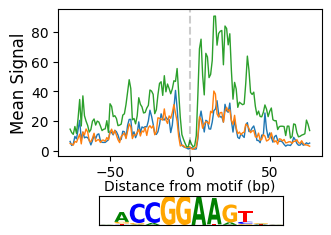

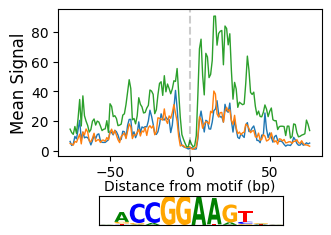

In [7]:
plot_topN_average_line([erg_fp_df, elf1_fp_df, erg_elf1_fp_df], pfm_path=ets_representative_pfm)